In [ ]:
!pip install -q -U "numpy<2.0"

In [ ]:
!pip -q install hdbscan umap-learn tslearn seaborn umap-learn==0.5.6 seaborn==0.13.2 plotly==5.24.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 372.7/372.7 kB 5.9 MB/s eta 0:00:00


In [ ]:
!pip -q install scikit-learn-extra

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 10.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import numpy as np
import pandas as pd

import os, sys, gc, math, random, time
from pprint import pprint

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

from sklearn import datasets
from sklearn.datasets import make_blobs, load_iris, make_moons, load_breast_cancer, make_swiss_roll
from sklearn.preprocessing import StandardScaler, MinMaxScaler, normalize, Normalizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, SpectralClustering, AgglomerativeClustering, DBSCAN
from sklearn import metrics
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score, normalized_mutual_info_score,
    davies_bouldin_score, calinski_harabasz_score, rand_score,
    accuracy_score, f1_score, silhouette_score
)
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline, Pipeline

from sklearn.decomposition import PCA, TruncatedSVD, IncrementalPCA, FastICA, NMF
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.svm import OneClassSVM, LinearSVC

from sklearn.manifold import TSNE, Isomap, LocallyLinearEmbedding
from sklearn.linear_model import LogisticRegression

import umap

from sklearn_extra.cluster import KMedoids
from scipy.cluster.hierarchy import dendrogram

import hdbscan
import umap.umap_ as umap
from tslearn.clustering import TimeSeriesKMeans

In [ ]:
import warnings
warnings.filterwarnings("ignore")


SEED = 42
np.random.seed(SEED)
random.seed(SEED)

sns.set(style="whitegrid", context="notebook")

## Кластеризация

### Утилиты

In [ ]:
def plot_clusters_2d(X, labels, title="", centers=None):
    plt.figure(figsize=(6,5))
    plt.scatter(X[:,0], X[:,1], c=labels, s=20, cmap='tab10')
    if centers is not None:
        plt.scatter(centers[:,0], centers[:,1], c='black', s=120, marker='x', label='centers')
        plt.legend()
    plt.title(title)
    plt.show()

def elbow_silhouette_scan(X, k_range=range(2,11), random_state=42, n_init=10):
    inertias, silhouettes = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=n_init, random_state=random_state)
        km.fit(X)
        inertias.append(km.inertia_)
        sil = silhouette_score(X, km.labels_) if k > 1 else np.nan
        silhouettes.append(sil)
    fig, ax = plt.subplots(1,2, figsize=(10,4))
    ax[0].plot(list(k_range), inertias, '-o')
    ax[0].set_title('Elbow: inertia vs k')
    ax[0].set_xlabel('k'); ax[0].set_ylabel('Inertia')
    ax[1].plot(list(k_range), silhouettes, '-o')
    ax[1].set_title('Silhouette vs k')
    ax[1].set_xlabel('k'); ax[1].set_ylabel('Silhouette')
    plt.show()

def k_distance_plot(X, k):
    nbrs = NearestNeighbors(n_neighbors=k).fit(X)
    distances, _ = nbrs.kneighbors(X)
    d_k = np.sort(distances[:, -1])
    plt.figure(figsize=(6,4))
    plt.plot(d_k)
    plt.title(f'k-distance plot (k={k})')
    plt.xlabel('Points sorted by distance')
    plt.ylabel('Distance to k-th neighbor')
    plt.show()

def print_internal_metrics(X, labels, name=""):
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    print(f"{name}: silhouette={sil:.3f}, DB={db:.3f} (меньше лучше), CH={ch:.1f} (больше лучше)")

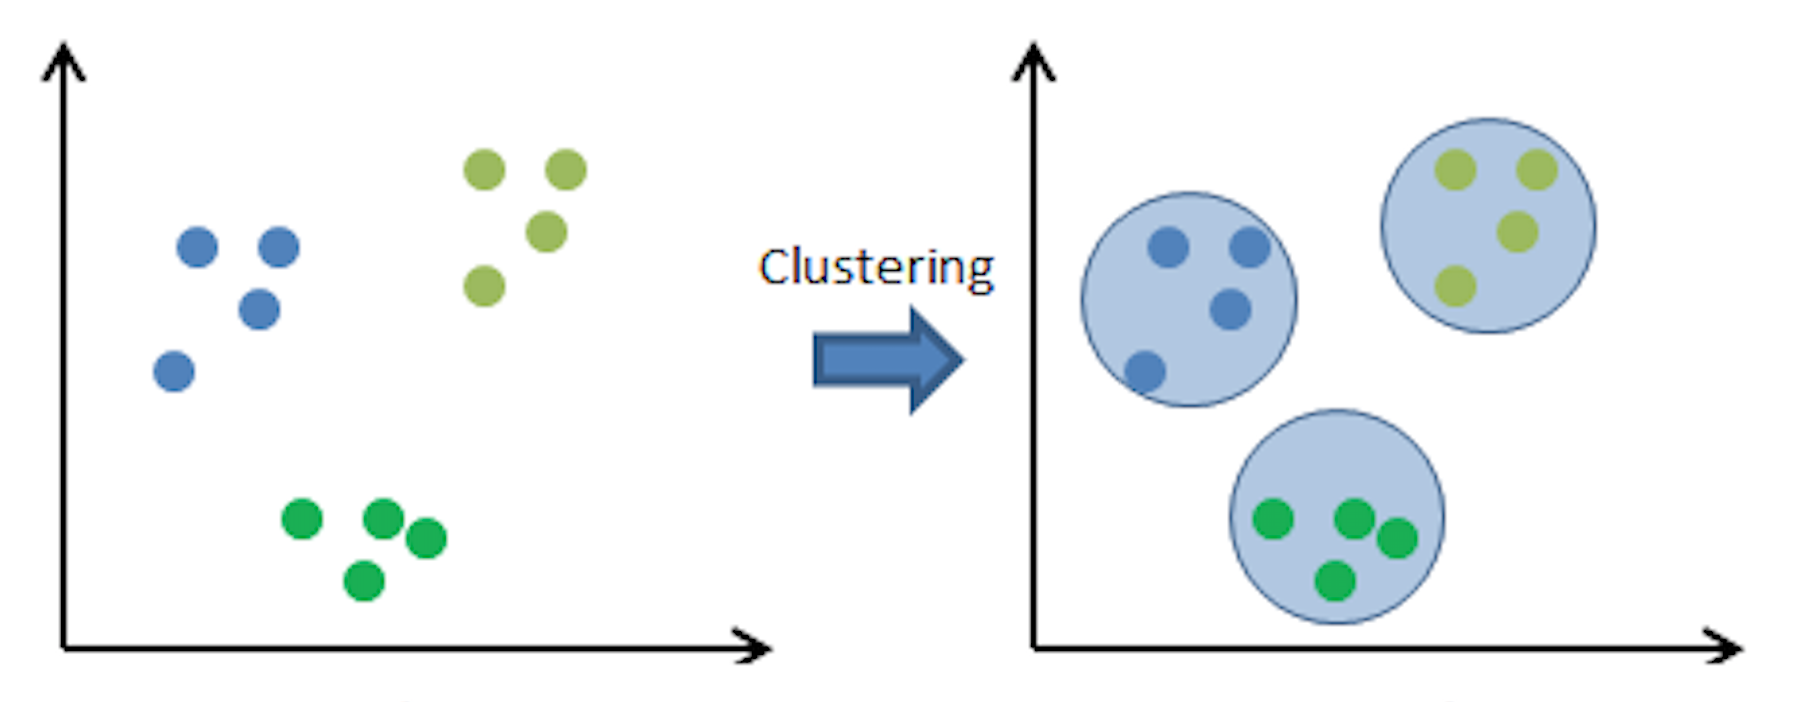

### Зачем?

- Классификация объектов. Попытка понять зависимости между объектами путем выявления их кластерной структуры.
- Сжатие данных. Можно сократить размер исходной выборки, взяв один или несколько наиболее типичных представителей каждого кластера.
- Выделение аномалий - объектов, которые не подходят по критериям ни в один кластер. Обнаруженные объекты в дальнейшем обрабатывают отдельно.

Теорема Клейнберга, что **не существует универсального "идеального" алгоритма кластеризации**, который одновременно бы удовлетворял трём основным аксиомам (требованиям) для любой структуры данных. Это фундаментальное ограничение — результат попытки формализовать интуитивные ожидания от кластеризации.

Клейнберг сформулировал кластеризацию в терминах задачи разбиения множества точек с метрическим расстоянием между ними. Он предложил 3 аксиомы для функций кластеризации:

1. Scale-Invariance (Масштабная инвариантность)
Результат кластеризации не должен меняться, если все расстояния между объектами умножить на одно и то же положительное число.
Пример: Если в исходных данных расстояния увеличили в 10 раз, "смысл" кластеров должен остаться тем же.

2. Richness (Богатство)
Для любого возможного разбиения множества на кластеры существует метрика (расстояния), которая приведёт к выбору именно этого разбиения.
Иными словами, алгоритм кластеризации должен быть достаточно "гибким", чтобы быть способным выделить любую возможную кластерную структуру при подходящей настройке метрики.

3. Consistency (Согласованность)
Если уменьшить расстояния внутри существующих кластеров и/или увеличить между кластерами (делая кластеры более "чёткими"), то разбиение на кластеры не должно измениться.
Пример: Сделав точки внутри кластера ещё ближе друг к другу, а между кластерами ещё дальше,

**Утверждение Клейнберга**:
"Нет такой процедуры кластеризации, которая бы выполняла одновременно все три аксиомы для произвольных данных (в любых метрических пространствах)."

Что это значит для нас?

- Наша задача - выбрать критерии кластеризации исходя из задачи - нет правильного универсального алгоритма, выбор алгоритма, числа кластеров, метрики - это всегда компромисс.

- Оценка кластеризации всегда специфична для предметной области.

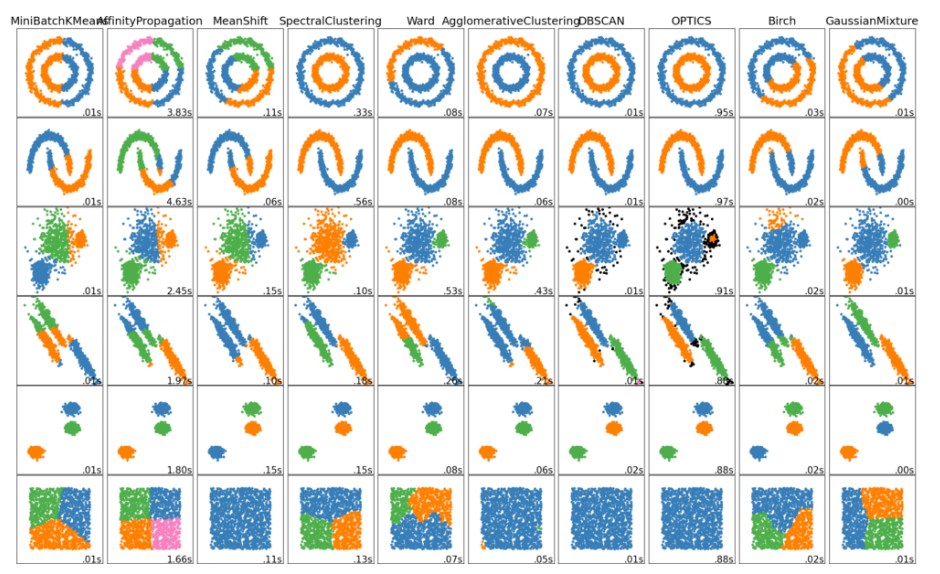

### K-means

#### Основная идея метода

Итеративное повторение двух шагов:

- Распределение объектов выборки по кластерам
- Пересчёт центров кластеров

Более подробно:

- Выбираются k центров будущих кластеров
- Каждый объект относят к одному из выбранных центров, ориентируясь на расстояние
- Центры кластеров пересчитываются как среднее арифметическое векторов вошедших в этот кластер объектов и обновляются
- Объекты относят к новым центрам кластеров
- ...

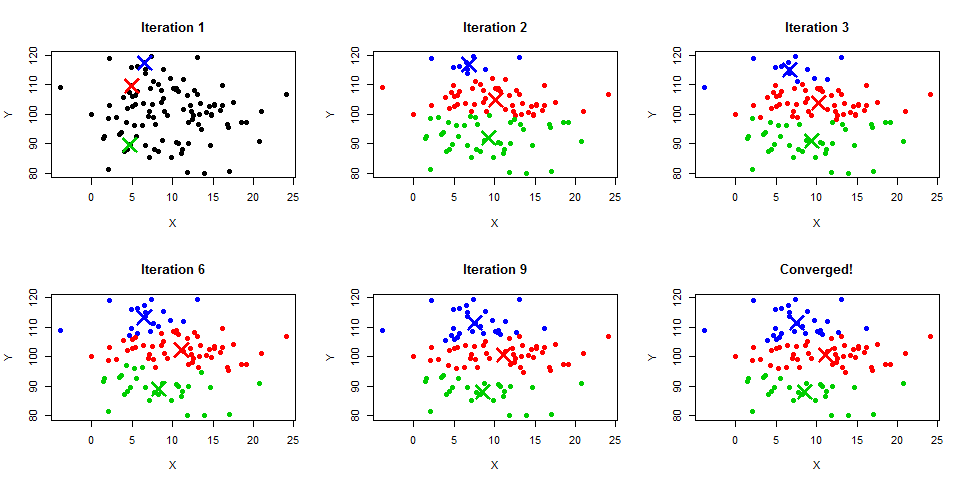

#### Проблемы

- Чувствительность к начальной инициализации
- Заранее необходимо знать k

#### Как подобрать количество кластеров?

Метод локтя

In [ ]:
X, y = make_blobs(n_samples=1000, centers=5, n_features=2, shuffle=True, random_state=2025)

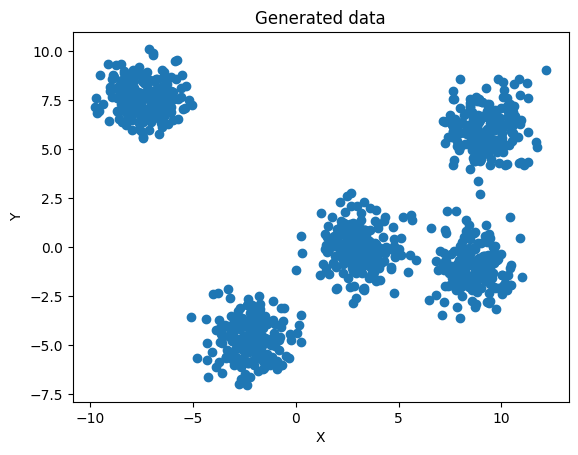

In [ ]:
plt.scatter(X[:, 0], X[:, 1])
plt.title('Generated data')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

`inertia_` - сумма квадратов расстояний от объектов до ближайших центров кластеров

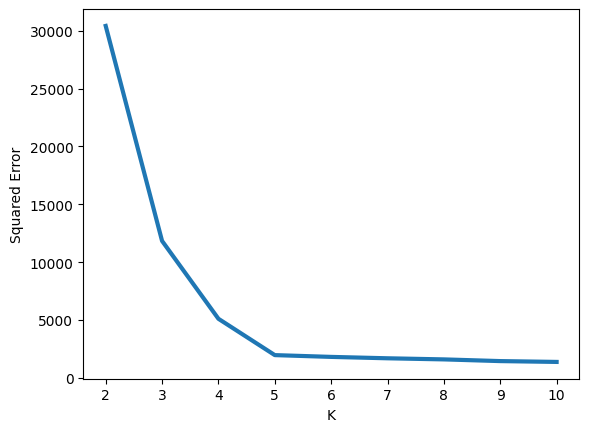

CPU times: user 291 ms, sys: 58.3 ms, total: 349 ms
Wall time: 366 ms


In [ ]:
%%time

se = []

for k in range(2, 11):
    clustering = KMeans(n_clusters=k, random_state=2024)
    clustering.fit(X)
    se.append(clustering.inertia_)

plt.plot(range(2, 11), se, linewidth='3')
plt.xlabel("K")
plt.ylabel("Squared Error")
plt.show()

Силуэт

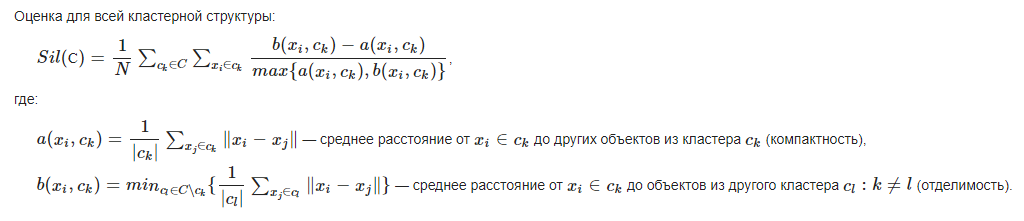

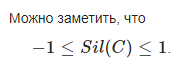

In [ ]:
silhouette = []

for k in range(2, 11):
  clustering = KMeans(n_clusters=k, random_state=2024).fit(X)
  labels = clustering.labels_
  silhouette.append(silhouette_score(X, labels, metric='euclidean'))

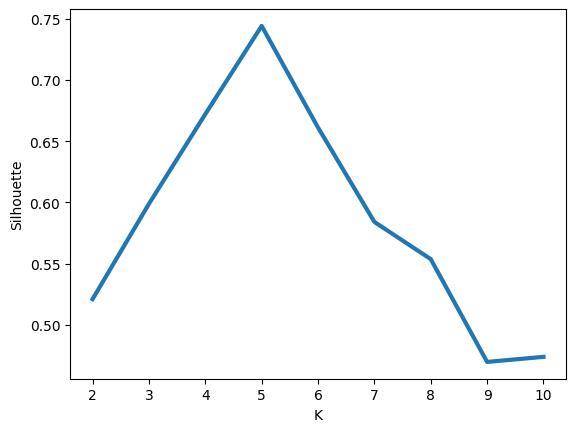

In [ ]:
plt.plot(range(2, 11), silhouette, linewidth='3')
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.show()

### Метрики качества

#### Индекс Rand

Доля пар объектов, для которых два разбиения согласны: либо оба в одном кластере в обоих разбиениях, либо в разных в обоих.

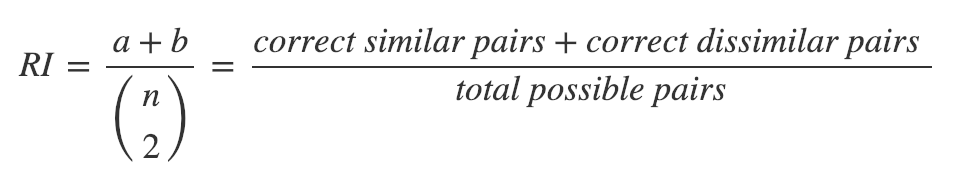

In [ ]:
rand_score([0, 0, 1, 2], [0, 0, 1, 1])

0.8333333333333334

#### Adjusted Rand Index

Тот же Rand Index с линейной нормировкой на “ожидаемое сходство случайных разметок”

In [ ]:
adjusted_rand_score([0, 0, 1, 2], [0, 0, 1, 1])

0.5714285714285714

#### NMI



Идея: сравнивает две разметки (например, истинные классы и кластеры) по информации, которую они дают друг о друге. Используется, когда есть ground truth.

#### Индекс Calinski–Harabasz

Компактность основана на расстоянии от точек кластера до их центроидов, а разделимость - на расстоянии от центроид кластеров до глобального центроида. Должен возрастать.

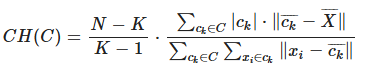

Идея: отношение межкластерной дисперсии к внутрикластерной. Выше — лучше.

#### Индекс Дэвиcа-Болдуина (англ. Davies–Bouldin Index)

Вычисляет компактность как расстояние от объектов кластера до их центроидов, а отделимость - как расстояние между центроидами.


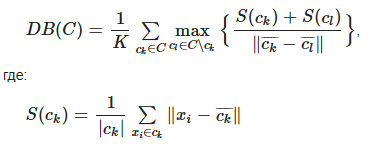


Идея: среднее "плохое" отношение разброса внутри кластеров к расстоянию между ближайшими кластерами. Ниже — лучше.

[Оценка качества в задаче кластеризации](https://neerc.ifmo.ru/wiki/index.php?title=%D0%9E%D1%86%D0%B5%D0%BD%D0%BA%D0%B0_%D0%BA%D0%B0%D1%87%D0%B5%D1%81%D1%82%D0%B2%D0%B0_%D0%B2_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%D0%B5_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D0%B8)

### Эффект масштабирования на KMeans и выбор k

In [ ]:
wine = datasets.load_wine()
X_raw = wine.data
y_true = wine.target  # есть "истинные" классы - удобно оценивать качество!

X_raw.shape, wine.feature_names

((178, 13),
 ['alcohol',
  'malic_acid',
  'ash',
  'alcalinity_of_ash',
  'magnesium',
  'total_phenols',
  'flavanoids',
  'nonflavanoid_phenols',
  'proanthocyanins',
  'color_intensity',
  'hue',
  'od280/od315_of_diluted_wines',
  'proline'])

In [ ]:
pd.DataFrame(X_raw[:5], columns=wine.feature_names)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


KMeans без скейлинга: ARI=0.371, NMI=0.429
KMeans со скейлингом: ARI=0.897, NMI=0.876


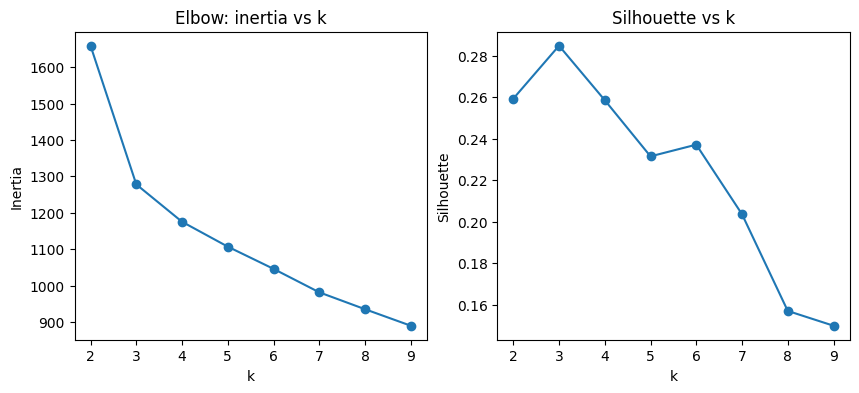

KMeans k=2: silhouette=0.259, DB=1.526 (меньше лучше), CH=69.5 (больше лучше)
KMeans k=3: silhouette=0.285, DB=1.389 (меньше лучше), CH=70.9 (больше лучше)
KMeans k=4: silhouette=0.259, DB=1.817 (меньше лучше), CH=56.2 (больше лучше)
KMeans k=5: silhouette=0.232, DB=1.681 (меньше лучше), CH=47.2 (больше лучше)


In [ ]:
# Без масштабирования
km_raw = KMeans(n_clusters=3, n_init=20, random_state=42).fit(X_raw)
ari_raw = adjusted_rand_score(y_true, km_raw.labels_)
nmi_raw = normalized_mutual_info_score(y_true, km_raw.labels_)
print(f"KMeans без скейлинга: ARI={ari_raw:.3f}, NMI={nmi_raw:.3f}")

# С масштабированием
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
km_scaled = KMeans(n_clusters=3, n_init=20, random_state=42).fit(X)
ari_scaled = adjusted_rand_score(y_true, km_scaled.labels_)
nmi_scaled = normalized_mutual_info_score(y_true, km_scaled.labels_)
print(f"KMeans со скейлингом: ARI={ari_scaled:.3f}, NMI={nmi_scaled:.3f}")

# "Локоть" и силуэт (после масштабирования)
elbow_silhouette_scan(X, k_range=range(2,10), n_init=20)

# Внутренние метрики для k=2..5
for k in range(2,6):
    km = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X)
    print_internal_metrics(X, km.labels_, name=f"KMeans k={k}")

- Без масштабирования признак с большим масштабом доминирует.
- «Локоть» может быть размытым; силуэт может переоценивать «выпуклые» кластеры.


### Стабильность KMeans: влияние n_init/random_state

In [ ]:
X = StandardScaler().fit_transform(datasets.load_wine().data)
k = 3

def run_many(n_init, repeats=10):
    labels = []
    for r in range(repeats):
        km = KMeans(n_clusters=k, n_init=n_init, random_state=r).fit(X)
        labels.append(km.labels_)
    # AMI между всеми парами
    amis = []
    for i in range(len(labels)):
        for j in range(i+1, len(labels)):
            amis.append(normalized_mutual_info_score(labels[i], labels[j]))
    return np.mean(amis), np.std(amis)

for n_init in [1, 5, 10, 20, 50]:
    m, s = run_many(n_init, repeats=12)
    print(f"n_init={n_init}: средний AMI между перезапусками = {m:.3f} ± {s:.3f}")

n_init=1: средний AMI между перезапусками = 0.949 ± 0.044
n_init=5: средний AMI между перезапусками = 0.982 ± 0.025
n_init=10: средний AMI между перезапусками = 0.996 ± 0.010
n_init=20: средний AMI между перезапусками = 1.000 ± 0.000
n_init=50: средний AMI между перезапусками = 1.000 ± 0.000


### Как выбросы ломают KMeans и что лучше в этом случае

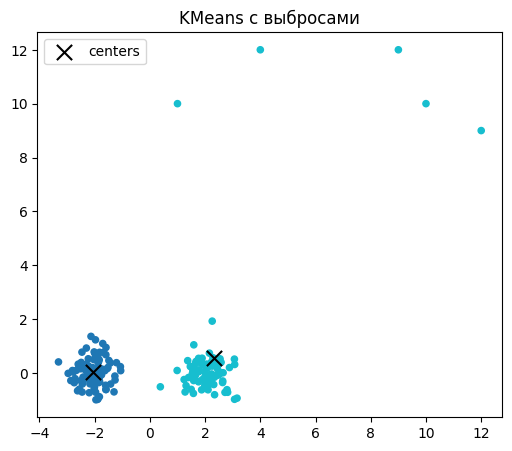

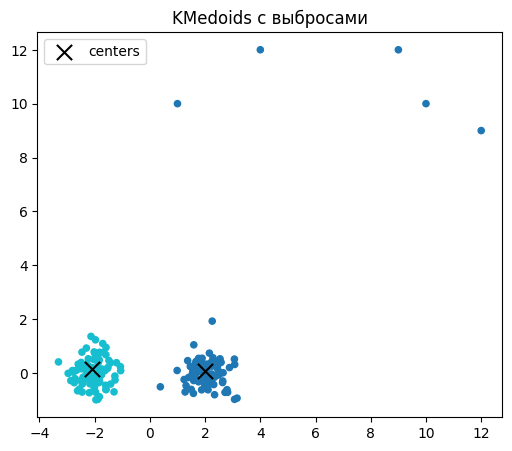

KMeans: silhouette=0.716, DB=0.455 (меньше лучше), CH=197.1 (больше лучше)
KMedoids: silhouette=0.716, DB=0.455 (меньше лучше), CH=197.1 (больше лучше)


In [ ]:
X_core, _ = make_blobs(n_samples=180, centers=[(-2,0), (2,0)], cluster_std=[0.5, 0.5], random_state=42)
outliers = np.array([[10, 10], [12, 9], [9, 12], [1, 10], [4, 12]])  # экстремальные выбросы
X = np.vstack([X_core, outliers])

# KMeans
km = KMeans(n_clusters=2, n_init=20, random_state=42).fit(X)
plot_clusters_2d(X, km.labels_, title="KMeans с выбросами", centers=km.cluster_centers_)

# KMedoids
kmed = KMedoids(n_clusters=2, metric='euclidean', random_state=42).fit(X)
plot_clusters_2d(X, kmed.labels_, title="KMedoids с выбросами", centers=kmed.cluster_centers_)

# Сравнение интуитивной устойчивости
print_internal_metrics(X, km.labels_, "KMeans")
print_internal_metrics(X, kmed.labels_, "KMedoids")

### Иерархическая кластеризация

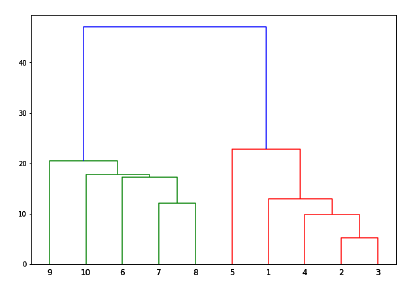

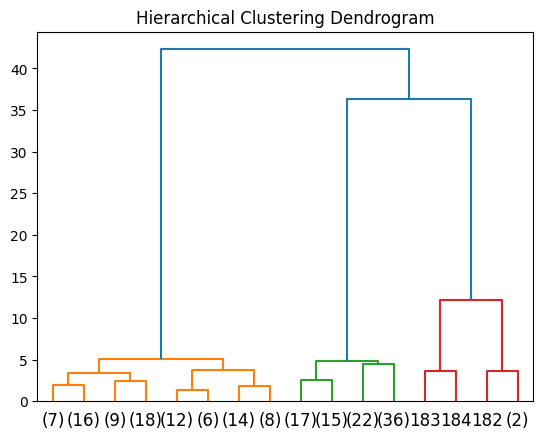

In [ ]:
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)


model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)

model = model.fit(X)
plt.title("Hierarchical Clustering Dendrogram")
plot_dendrogram(model, truncate_mode="level", p=3)
plt.show()

### DBSCAN

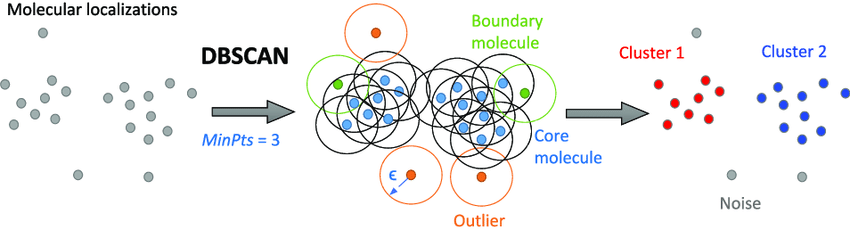

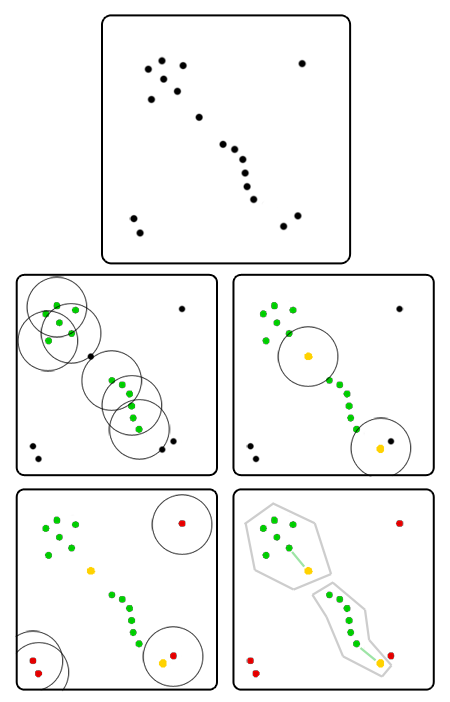

Алгоритм DBSCAN рассматривает кластеры, как участки высокой плотности, разделенные районами с низкой плотностью.

В алгоритме есть два параметра, `min_samples` и `eps`, которые формально определяют, что мы имеем в виду, когда говорим «плотный» . Высокие значения `min_samples` или низкие `eps` указывают на более высокую плотность, необходимую для формирования кластера.

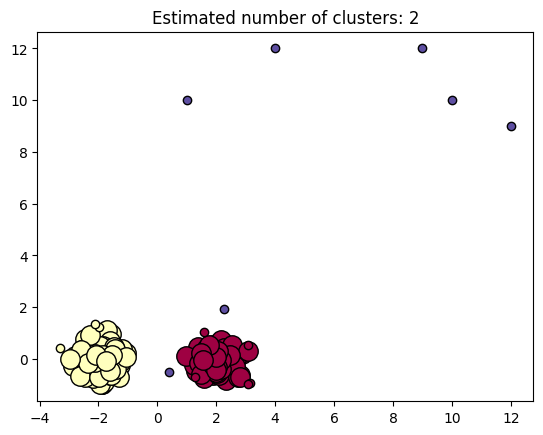

In [ ]:
scaled = StandardScaler().fit_transform(X)


db = DBSCAN(eps=0.3, min_samples=10).fit(scaled)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    class_member_mask = (labels == k)

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=14)

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=6)

plt.title('Estimated number of clusters: %d' % n_clusters_)
plt.show();

#### Невыпуклые кластеры

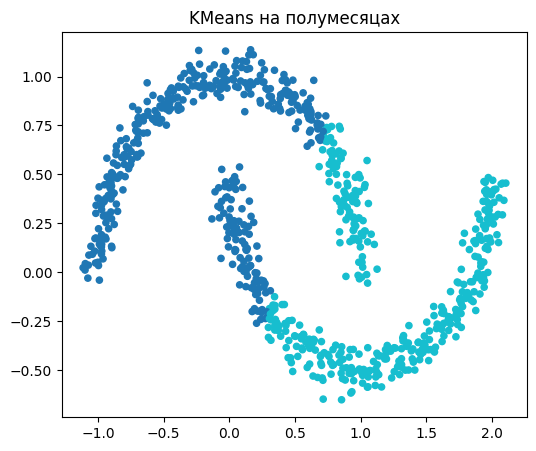

KMeans: silhouette=0.486, DB=0.784 (меньше лучше), CH=1173.1 (больше лучше)


In [ ]:
X, y_true = make_moons(n_samples=800, noise=0.06, random_state=42)

# KMeans
km = KMeans(n_clusters=2, n_init=20, random_state=42).fit(X)
plot_clusters_2d(X, km.labels_, title="KMeans на полумесяцах")
print_internal_metrics(X, km.labels_, "KMeans")

По оси Y отложено расстояние до 10‑го соседа для каждой точки, отсортированное по возрастанию

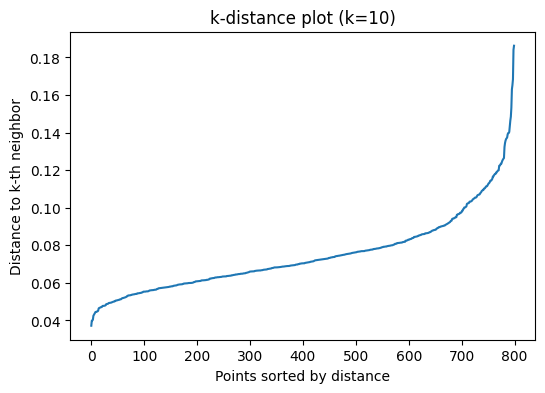

In [ ]:
k_distance_plot(X, k=10)

Оптимальный `eps - точка, где кривая меняет наклон с плавного на более крутой, перед почти вертикальным хвостом справа

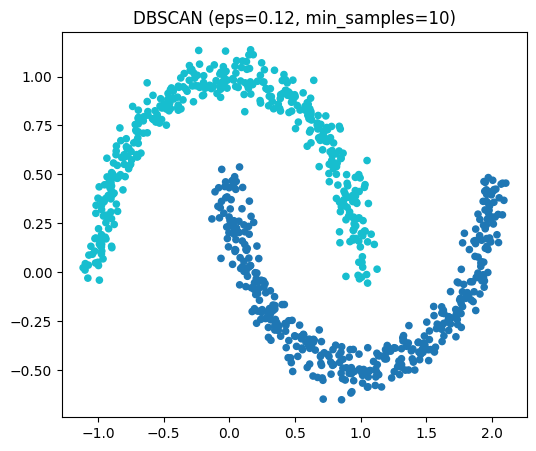

DBSCAN: silhouette=0.333, DB=1.156 (меньше лучше), CH=527.5 (больше лучше)


In [ ]:
# DBSCAN
db = DBSCAN(eps=0.12, min_samples=10).fit(X)
plot_clusters_2d(X, db.labels_, title="DBSCAN (eps=0.12, min_samples=10)")
print_internal_metrics(X, db.labels_, "DBSCAN")

- KMeans плохо работает на заведомо не-выпуклых формах
- Силуэт может не подсказать «не-выпуклость»
- В DBSCAN `eps` чувствителен к масштабу — нужно масштабировани и/или подбор через k-distance plot

#### Разная плотность: DBSCAN vs HDBSCAN

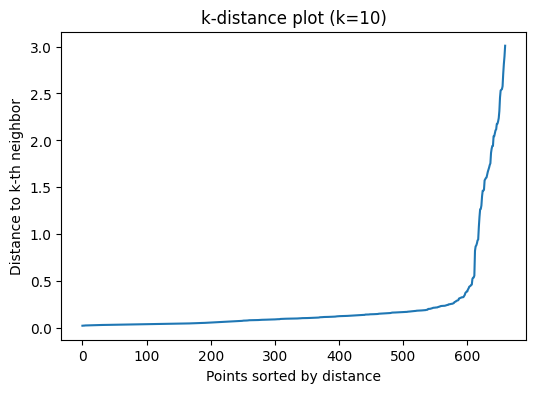

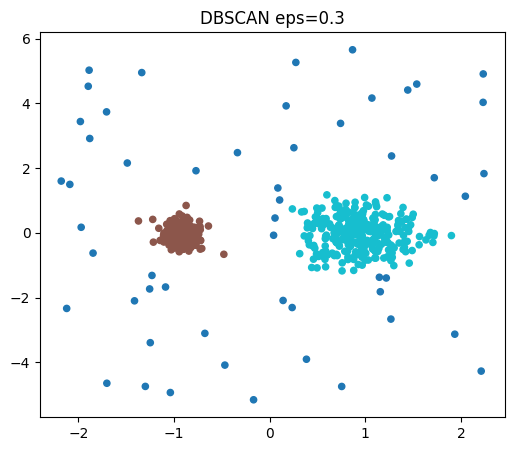

DBSCAN eps=0.3: silhouette=0.650, DB=3.668 (меньше лучше), CH=224.1 (больше лучше)


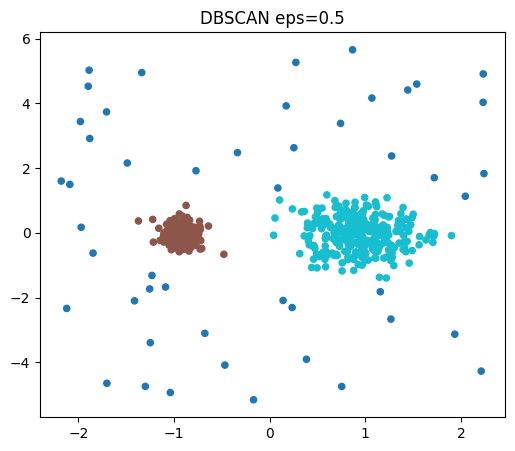

DBSCAN eps=0.5: silhouette=0.654, DB=3.882 (меньше лучше), CH=226.4 (больше лучше)


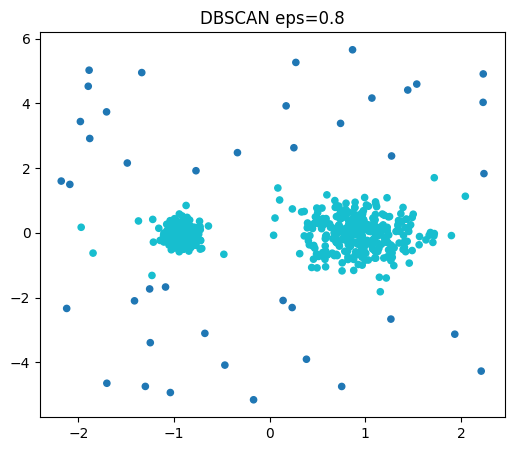

DBSCAN eps=0.8: silhouette=0.626, DB=8.190 (меньше лучше), CH=6.5 (больше лучше)


In [ ]:
rng = np.random.RandomState(42)

# Плотный кластер
C1 = rng.normal(loc=[-2,0], scale=[0.2,0.2], size=(300,2))

# Разреженный кластер
C2 = rng.normal(loc=[2,0], scale=[0.7,0.4], size=(300,2))

noise = rng.uniform(low=-5, high=5, size=(60,2))

X = np.vstack([C1,C2,noise])
X_scaled = StandardScaler().fit_transform(X)

k_distance_plot(X_scaled, k=10)

for eps in [0.3, 0.5, 0.8]:
    db = DBSCAN(eps=eps, min_samples=10).fit(X_scaled)
    plot_clusters_2d(X_scaled, db.labels_, title=f"DBSCAN eps={eps}")
    print_internal_metrics(X_scaled, db.labels_, name=f"DBSCAN eps={eps}")

HDBSCAN — это иерархический и более гибкий вариант DBSCAN, умеющий работать с кластерами разных плотностей, автоматически выбирать число кластеров и требующий меньше ручной настройки параметров.

HDBSCAN строит иерархию по плотностям (минимальное остовное дерево, дендрограмма по взаимной достижимости), отсекает шум/выбросы и может выделять кластеры разной плотности одновременно

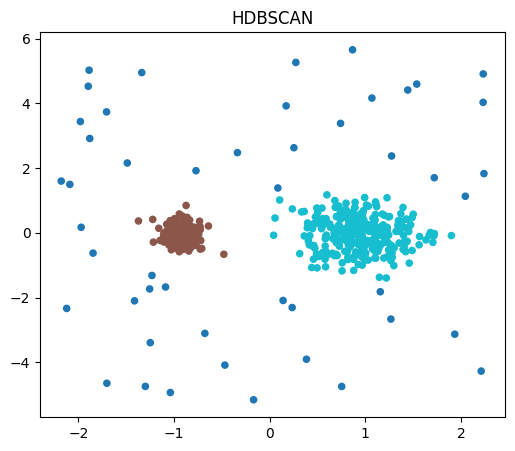

HDBSCAN: silhouette=0.654, DB=3.882 (меньше лучше), CH=226.4 (больше лучше)


In [ ]:
# HDBSCAN - не нужен eps
hdb = hdbscan.HDBSCAN(min_cluster_size=25, min_samples=10).fit(X_scaled)
plot_clusters_2d(X_scaled, hdb.labels_, title="HDBSCAN")
print_internal_metrics(X_scaled, hdb.labels_, "HDBSCAN")

### Time Series: KMeans (euclidean) vs TimeSeriesKMeans (DTW)

In [ ]:
rng = np.random.RandomState(42)
n_per = 30
L = 100
t = np.linspace(0, 2*np.pi, L)

def make_cluster_sin(phase):
    return np.sin(t + phase) + 0.1*rng.randn(L)

def make_cluster_square():
    return np.sign(np.sin(t)) + 0.1*rng.randn(L)

X_ts = []
y_ts = []
# Кластер 0: синусы, разные фазы
for ph in np.linspace(0, np.pi/2, n_per):
    X_ts.append(make_cluster_sin(ph)); y_ts.append(0)
# Кластер 1: синусы, другие фазы
for ph in np.linspace(np.pi/2, np.pi, n_per):
    X_ts.append(make_cluster_sin(ph)); y_ts.append(1)
# Кластер 2: квадратная волна
for _ in range(n_per):
    X_ts.append(make_cluster_square()); y_ts.append(2)

X_ts = np.array(X_ts)
y_ts = np.array(y_ts)

KMeans Euclidean: ARI= 0.6335734478462424
TimeSeriesKMeans DTW: ARI= 0.7213525360050094


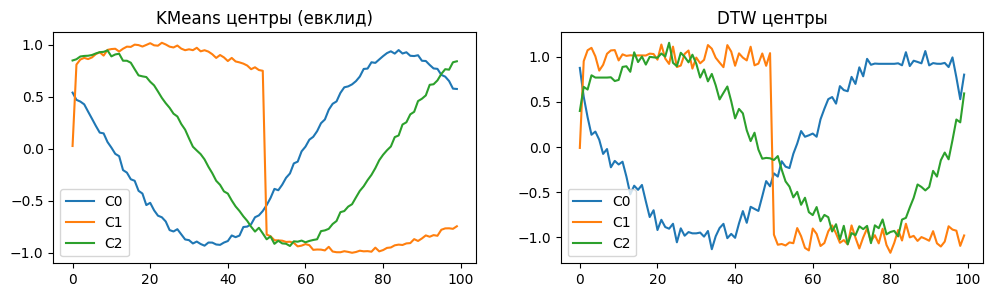

In [ ]:
# Обычный KMeans по плоским рядам (евклид)
km = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X_ts)
print("KMeans Euclidean: ARI=", adjusted_rand_score(y_ts, km.labels_))

# DTW KMeans
dtw_km = TimeSeriesKMeans(n_clusters=3, metric="dtw", max_iter=10, random_state=42, n_jobs=-1).fit(X_ts)
print("TimeSeriesKMeans DTW: ARI=", adjusted_rand_score(y_ts, dtw_km.labels_))

# Визуализируем средние центроиды
fig, ax = plt.subplots(1,2, figsize=(12,3))
for k in range(3):
    ax[0].plot(km.cluster_centers_[k], label=f'C{k}')
ax[0].set_title('KMeans центры (евклид)')
ax[0].legend()

for k in range(3):
    ax[1].plot(dtw_km.cluster_centers_[k].ravel(), label=f'C{k}')
ax[1].set_title('DTW центры')
ax[1].legend()
plt.show()

- В KMeans центроиды сглажены и немного усредняют фазы сигналов.
Похоже, что из‑за сдвигов по времени разные формы внутри кластера частично накладываются, и центры выглядят компромиссно (меньше амплитуда, размытые переходы).

- В DTW кривые выглядят как более чёткие прототипы трёх разных типов траекторий, с сохранением характерных фаз и форм. DTW компенсирует сдвиги по времени, поэтому центры отражают именно рисунок ряда, а не точное совпадение по координатам.

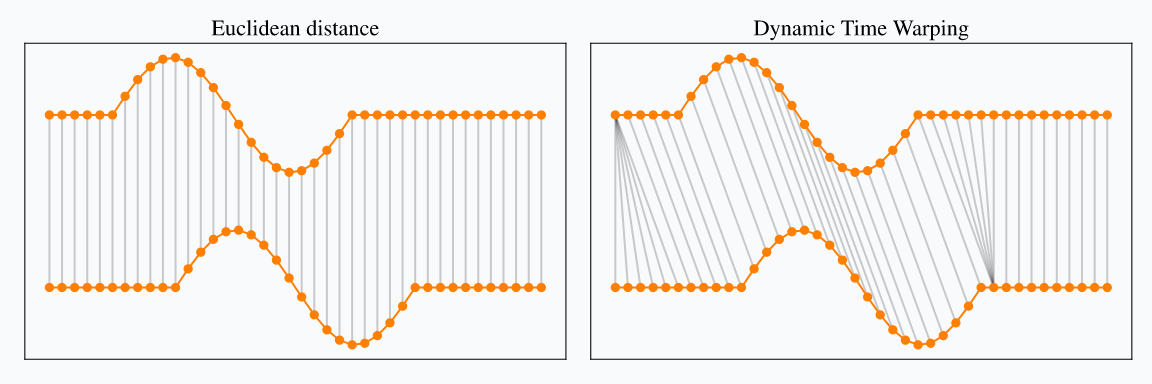

## Снижение размерности - Метод главных компонент (PCA)

[Метод главных компонент. Пошаговая инструкция.](https://vk.com/@itresume-metod-glavnyh-komponent-poshagovaya-instrukciya)

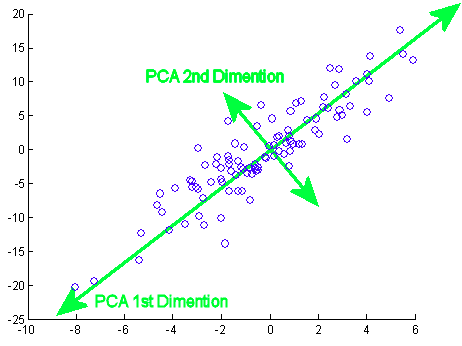

In [ ]:
X, y = load_iris(return_X_y=True, as_frame=True)
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
X = StandardScaler().fit_transform(X)

In [ ]:
pca = PCA(n_components=2)
res = pca.fit_transform(X)
res = pd.DataFrame(data=res, columns = ['component 1', 'component 2'])
res['target'] = y

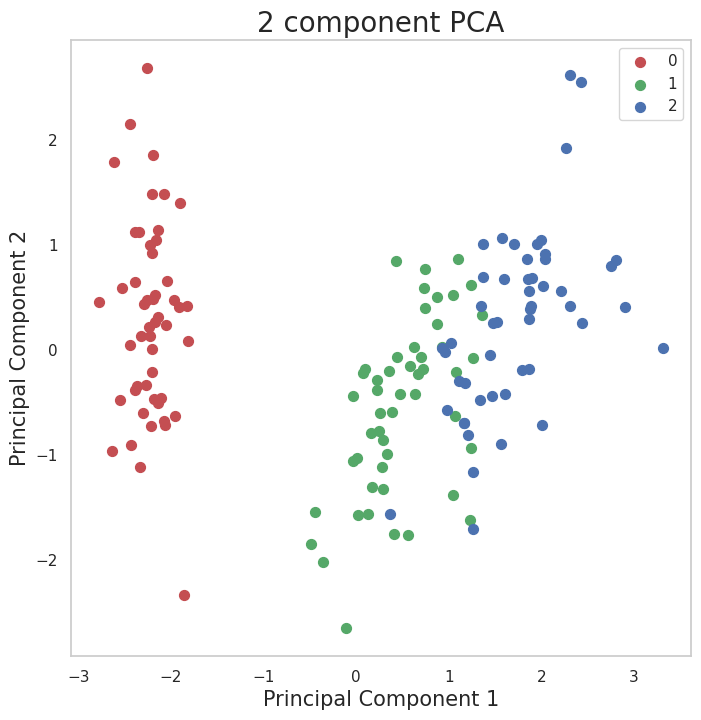

In [ ]:
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1)
ax.set_xlabel('Principal Component 1', fontsize = 15)
ax.set_ylabel('Principal Component 2', fontsize = 15)
ax.set_title('2 component PCA', fontsize = 20)
colors = ['r', 'g', 'b']

for target, color in zip(res['target'].unique(), colors):
    indicesToKeep = res['target'] == target
    ax.scatter(
        res.loc[indicesToKeep, 'component 1'],
        res.loc[indicesToKeep, 'component 2'],
        c=color,
        s=50
    )
ax.legend(res['target'].unique())
ax.grid()

#### Важность масштабирования

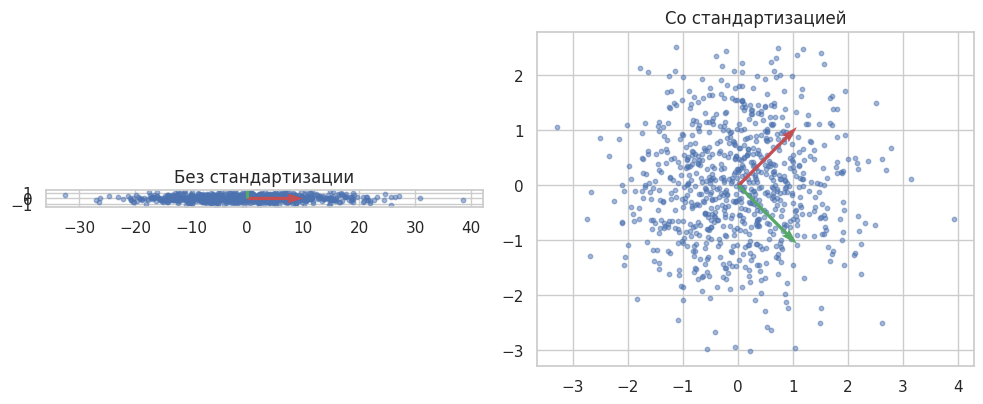

Explained variance ratio без стандартизации: [0.9974144 0.0025856]
Explained variance ratio со стандартизацией: [0.50932212 0.49067788]


In [ ]:
# Сгенерируем 2D данные: одна ось с большой дисперсией, другая - маленькой
n = 800
x1 = np.random.normal(loc=0.0, scale=10.0, size=n)  # крупная шкала
x2 = np.random.normal(loc=0.0, scale=0.5, size=n)   # мелкая шкала
X = np.vstack([x1, x2]).T

fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].scatter(X[:,0], X[:,1], s=10, alpha=0.5)
axes[0].set_title("Без стандартизации")
axes[0].set_aspect('equal', 'box')

# PCA без стандартизации
pca_raw = PCA(n_components=2, random_state=SEED).fit(X)
vecs = pca_raw.components_
mean = pca_raw.mean_
axes[0].quiver(mean[0], mean[1], vecs[0,0]*10, vecs[0,1]*10, angles='xy', scale_units='xy', scale=1, color='r')
axes[0].quiver(mean[0], mean[1], vecs[1,0]*10, vecs[1,1]*10, angles='xy', scale_units='xy', scale=1, color='g')

# Со стандартизацией
Xz = StandardScaler().fit_transform(X)
axes[1].scatter(Xz[:,0], Xz[:,1], s=10, alpha=0.5)
axes[1].set_title("Со стандартизацией")
axes[1].set_aspect('equal', 'box')

pca_std = PCA(n_components=2, random_state=SEED).fit(Xz)
vecs2 = pca_std.components_
mean2 = pca_std.mean_
axes[1].quiver(mean2[0], mean2[1], vecs2[0,0]*1.5, vecs2[0,1]*1.5, angles='xy', scale_units='xy', scale=1, color='r')
axes[1].quiver(mean2[0], mean2[1], vecs2[1,0]*1.5, vecs2[1,1]*1.5, angles='xy', scale_units='xy', scale=1, color='g')

plt.tight_layout()
plt.show()

print("Explained variance ratio без стандартизации:", pca_raw.explained_variance_ratio_)
print("Explained variance ratio со стандартизацией:", pca_std.explained_variance_ratio_)

#### Выбор числа компонент: объясненная дисперсия — не всегда критерий под задачу

In [ ]:
data = load_breast_cancer()
X, y = data.data, data.target

# Сравним точность логистической регрессии при разных n_components
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(whiten=False, random_state=SEED)),
    ("clf", LogisticRegression(max_iter=2000, n_jobs=None))
])

param_grid = {"pca__n_components": [2, 5, 10, 15, 20, 25, None]}  # None = все компоненты
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
gs = GridSearchCV(pipe, param_grid, scoring="accuracy", cv=cv, n_jobs=-1)
gs.fit(X, y)
print("Лучшая точность:", gs.best_score_, "при n_components =", gs.best_params_["pca__n_components"])

Лучшая точность: 0.9771774569166279 при n_components = 10


Сравним с критерием реконструкции (MSE на валидации)

In [ ]:
recons = []
for k in [2,5,10,15,20,25,X.shape[1]]:
    p = Pipeline([("scaler", StandardScaler()), ("pca", PCA(n_components=None if k==X.shape[1] else k, random_state=SEED))])
    Xz = p.fit_transform(X)  # только до PCA, без clf
    X_back = p.named_steps["pca"].inverse_transform(Xz)
    mse = np.mean((p.named_steps["scaler"].inverse_transform(X_back) - X)**2)
    recons.append((k, mse))
print("MSE реконструкции vs k:", recons)

MSE реконструкции vs k: [(2, 809.7927504717511), (5, 729.8173415293901), (10, 515.55815175695), (15, 249.0515237792932), (20, 51.40359070900975), (25, 23.286912107010615), (30, 1.4930511558775316e-26)]


Часто k, оптимальное по точности классификации, не совпадает с k, оптимальным по MSE реконструкции.

Необходимо выбирать критерий под задачу

#### PCA & текстовые данные

In [ ]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp

cats = ['comp.graphics', 'sci.space', 'rec.sport.hockey', 'talk.politics.misc']
newsg = fetch_20newsgroups(subset='train', categories=cats, remove=('headers','footers','quotes'))
len(newsg.data), len(newsg.target_names)

(2242, 4)

In [ ]:
vectorizer = TfidfVectorizer(max_features=20000, min_df=2)
X_text = vectorizer.fit_transform(newsg.data)
y_text = newsg.target
print("TF-IDF shape:", X_text.shape, "sparse density:", X_text.nnz / (X_text.shape[0]*X_text.shape[1]))

TF-IDF shape: (2242, 14446) sparse density: 0.0064251092042554615


Попробуем оценить память без CSR

In [ ]:
bytes_dense = X_text.shape[0] * X_text.shape[1] * 8  # float64 ~8 байт
print(f"~{bytes_dense/1024/1024/1024:.2f} GB")

~0.24 GB


In [ ]:
# Базовая модель без DR
base = Pipeline([
    ("clf", LogisticRegression(max_iter=2000, n_jobs=None))
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
base_score = cross_val_score(base, X_text, y_text, cv=cv, scoring="accuracy", n_jobs=-1).mean()
print("Базовая логрегрессия на TF-IDF (без DR):", base_score)

# LSA: TruncatedSVD + нормировка + логрегрессия
lsa = Pipeline([
    ("svd", TruncatedSVD(n_components=100, random_state=SEED)),
    ("norm", Normalizer(copy=False)),
    ("clf", LogisticRegression(max_iter=2000))
])
lsa_score = cross_val_score(lsa, X_text, y_text, cv=cv, scoring="accuracy", n_jobs=-1).mean()
print("LSA (100 комп.):", lsa_score)

# Поиском подберем n_components
grid = {"svd__n_components": [50, 100, 200, 300]}
gs = GridSearchCV(lsa, grid, cv=cv, scoring="accuracy", n_jobs=-1)
gs.fit(X_text, y_text)
print("Лучшая точность LSA:", gs.best_score_, "при", gs.best_params_)

Базовая логрегрессия на TF-IDF (без DR): 0.8804575644288896
LSA (100 комп.): 0.8608355870187718
Лучшая точность LSA: 0.8724208558701877 при {'svd__n_components': 300}


- StandardScaler к sparse матрицам применять нельзя: он центрует признаки около 0 и разреженность теряется.
- Для TF-IDF типичный стек: TruncatedSVD -> Normalizer -> линейный классификатор.
- Слишком маленькое число компонент может срезать важные термины → деградация.

### PCA vs Isomap/LLE/UMAP

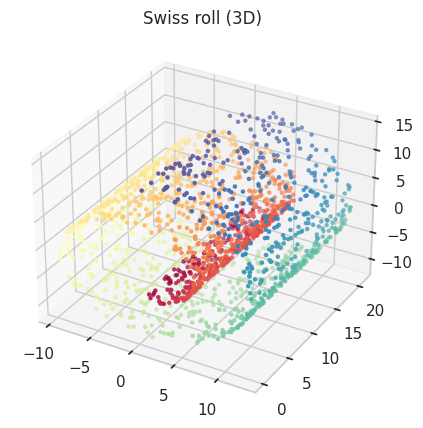

In [ ]:
X_swiss, color = make_swiss_roll(n_samples=2000, noise=0.05, random_state=SEED)

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(X_swiss[:,0], X_swiss[:,1], X_swiss[:,2], c=color, cmap=plt.cm.Spectral, s=5)
ax.set_title("Swiss roll (3D)")
plt.show()

PCA в 2D - рулетик не разворачивается

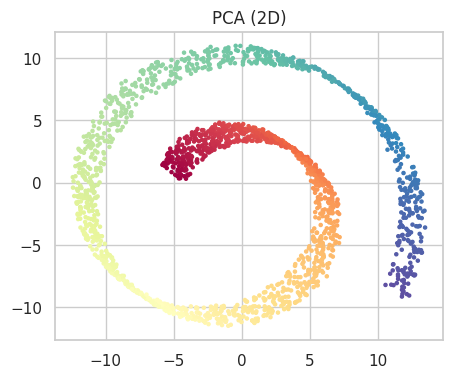

In [ ]:
X_pca2 = PCA(n_components=2, random_state=SEED).fit_transform(X_swiss)
plt.figure(figsize=(5,4))
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=color, cmap=plt.cm.Spectral, s=5)
plt.title("PCA (2D)")
plt.show()

Рулетик не разворачивается

**Isomap, LLE и UMAP** - это нелинейные методы снижения размерности, которые пытаются сохранить геометрию многообразия данных, в отличие от линейного PCA, который сохраняет только глобальную линейную структуру (максимальную дисперсию по прямым осям)

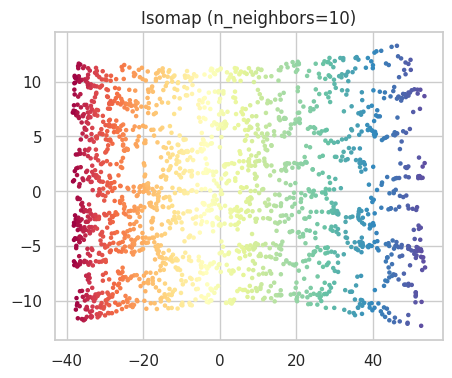

In [ ]:
X_iso = Isomap(n_neighbors=10, n_components=2).fit_transform(X_swiss)
plt.figure(figsize=(5,4))
plt.scatter(X_iso[:,0], X_iso[:,1], c=color, cmap=plt.cm.Spectral, s=5)
plt.title("Isomap (n_neighbors=10)")
plt.show()

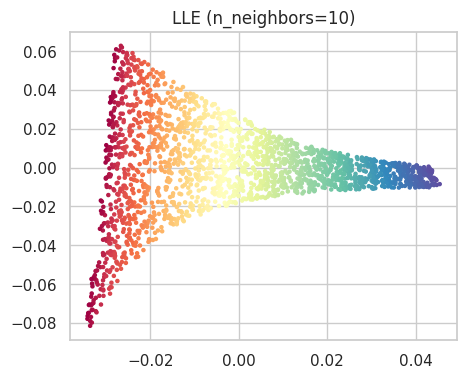

In [ ]:
# LLE
X_lle = LocallyLinearEmbedding(n_neighbors=10, n_components=2, method='standard', random_state=SEED).fit_transform(X_swiss)
plt.figure(figsize=(5,4))
plt.scatter(X_lle[:,0], X_lle[:,1], c=color, cmap=plt.cm.Spectral, s=5)
plt.title("LLE (n_neighbors=10)")
plt.show()

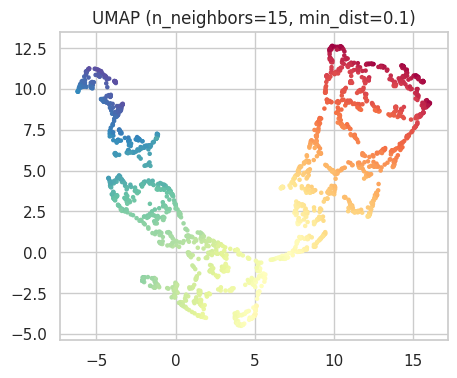

In [ ]:
# UMAP: чувствительность к параметрам
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=SEED)
X_umap = reducer.fit_transform(X_swiss)
plt.figure(figsize=(5,4))
plt.scatter(X_umap[:,0], X_umap[:,1], c=color, cmap=plt.cm.Spectral, s=5)
plt.title("UMAP (n_neighbors=15, min_dist=0.1)")
plt.show()

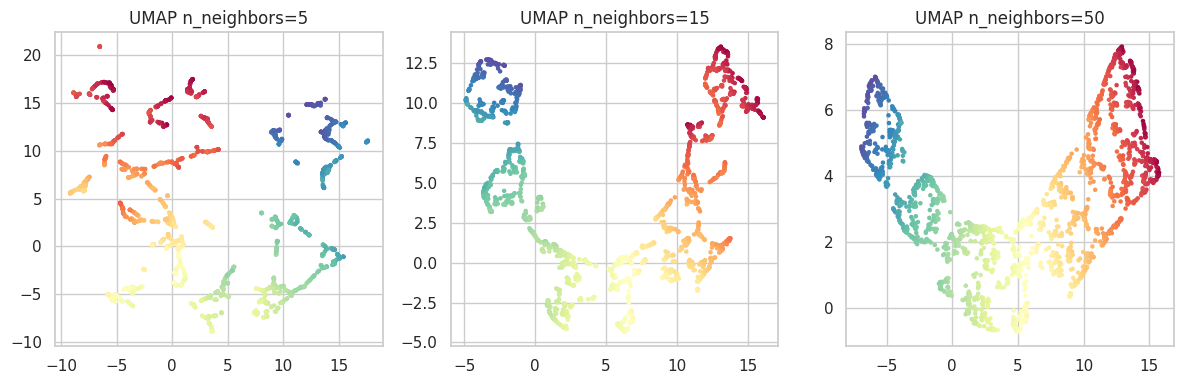

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(12,4))
for ax, k in zip(axes, [5, 15, 50]):
    X_u = umap.UMAP(n_neighbors=k, min_dist=0.05, random_state=SEED).fit_transform(X_swiss)
    ax.scatter(X_u[:,0], X_u[:,1], c=color, cmap=plt.cm.Spectral, s=5)
    ax.set_title(f"UMAP n_neighbors={k}")
plt.tight_layout()
plt.show()

Итого: PCA - линейный; Isomap, LLE, UMAP - нелинейные.

Что сохраняют:

- PCA — глобальную дисперсию (ковариационную структуру).
- Isomap — глобальные геодезические расстояния по многообразию.
- LLE — локальные линейные отношения с соседями.
- UMAP — вероятностную структуру графа соседства (локальное соседство и кластерную структуру).

Когда полезны:

- PCA - быстрый базовый метод, предобработка, когда структура примерно линейна.

- Isomap / LLE — учебные и исследовательские примеры для явно нелинейных многообразий.

- UMAP — практическая нелинейная визуализация и кластеризация (особенно high‑dim embeddings, TF‑IDF, feature‑вектора).

### t-SNE

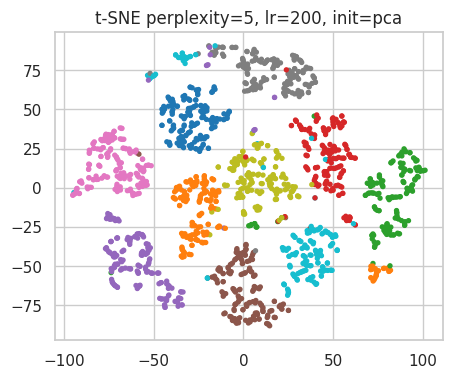

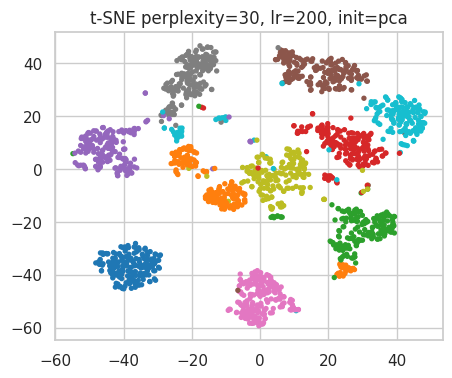

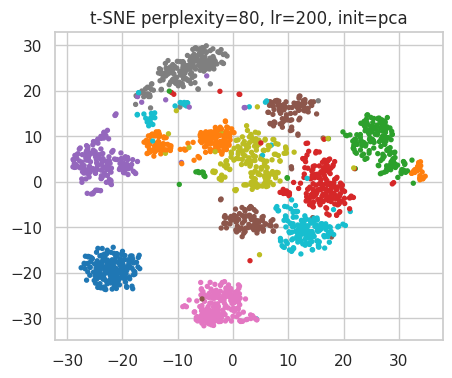

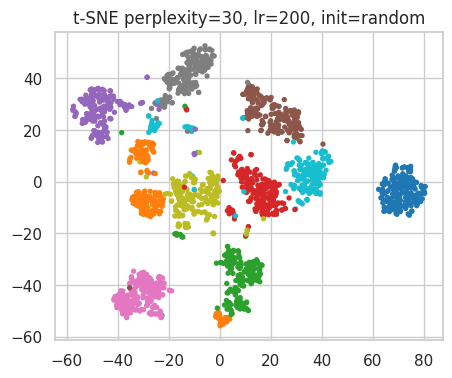

In [ ]:
digits = datasets.load_digits()
Xd, yd = digits.data, digits.target
Xd_z = StandardScaler().fit_transform(Xd)

def plot_tsne(perplexity, lr, init):
    tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, init=init, random_state=SEED, n_iter=1000)
    X_emb = tsne.fit_transform(Xd_z)
    plt.figure(figsize=(5,4))
    plt.scatter(X_emb[:,0], X_emb[:,1], c=yd, s=8, cmap='tab10')
    plt.title(f"t-SNE perplexity={perplexity}, lr={lr}, init={init}")
    plt.show()

for p in [5, 30, 80]:
    plot_tsne(perplexity=p, lr=200, init="pca")

# Разные random_state (через init="random"): другие лэйауты
plot_tsne(perplexity=30, lr=200, init="random")

- Глобальные расстояния и размеры кластеров в t-SNE неинтерпретируемы.
- Разная инициализация/seed - визуально разные графики.

#### Пример с классификацией

База: KNN на стандартизованных признаках

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

#
knn = KNeighborsClassifier(n_neighbors=5)
base_score = cross_val_score(knn, Xd_z, yd, cv=cv, scoring="accuracy").mean()
print("KNN на исходных (scaled) признаках:", base_score)

KNN на исходных (scaled) признаках: 0.9794073042401733


PCA как допустимый препроцессинг (pipeline)

In [ ]:
pipe_pca_knn = Pipeline([
    ("pca", PCA(n_components=30, random_state=SEED)),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])
pca_score = cross_val_score(pipe_pca_knn, Xd_z, yd, cv=cv, scoring="accuracy").mean()
print("KNN после PCA(30):", pca_score)

KNN после PCA(30): 0.9755075827917054


t-SNE не имеет корректного transform для новых точек в sklearn

In [ ]:
pipe_tsne_knn = Pipeline([
    ("tsne", TSNE(n_components=2, perplexity=30, learning_rate=200, init='pca', random_state=SEED)),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])
tsne_score = cross_val_score(pipe_tsne_knn, Xd_z, yd, cv=cv, scoring="accuracy").mean()
print("KNN после t-SNE:", tsne_score)

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 654, in fit
    Xt = self._fit(X, y, routed_params, raw_params=params)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 562, in _fit
 

## Поиск аномалий

### Isolation Forest

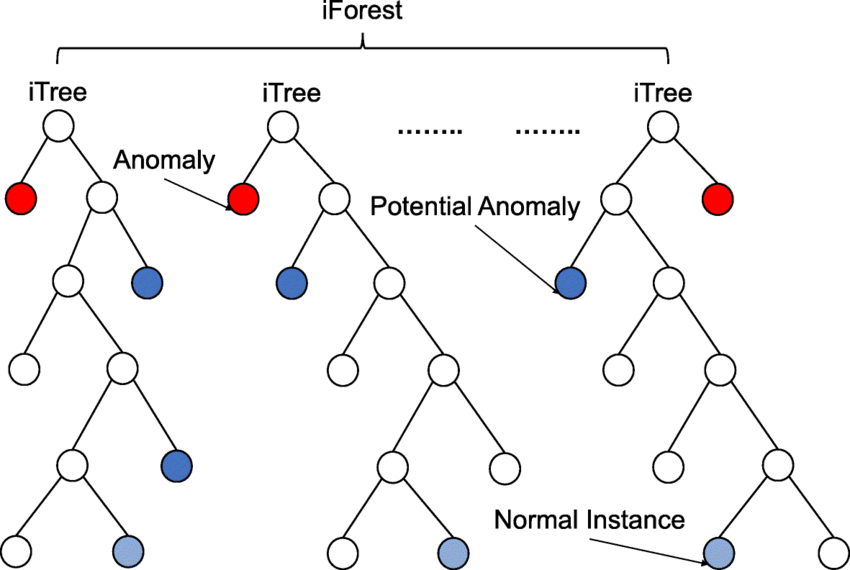

- Каждое дерево строится до исчерпании выборки
- Для построения ветвления в дереве: выбирается случайный признак и случайное расщепление
- Для каждого объекта мера его нормальности – среднее арифметическое глубин листьев, в которые он попал (изолировался)

In [ ]:
n_samples, n_outliers = 120, 40
rng = np.random.RandomState(2024)
covariance = np.array([[0.5, -0.1], [0.7, 0.4]])
cluster_1 = 0.4 * rng.randn(n_samples, 2) @ covariance + np.array([2, 2])  # general
cluster_2 = 0.3 * rng.randn(n_samples, 2) + np.array([-2, -2])  # spherical
outliers = rng.uniform(low=-4, high=4, size=(n_outliers, 2))

X = np.concatenate([cluster_1, cluster_2, outliers])
y = np.concatenate(
    [np.ones((2 * n_samples), dtype=int), -np.ones((n_outliers), dtype=int)]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

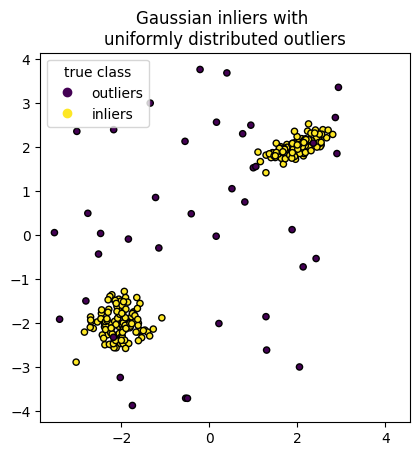

In [ ]:
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor="k")
handles, labels = scatter.legend_elements()
plt.axis("square")
plt.legend(handles=handles, labels=["outliers", "inliers"], title="true class")
plt.title("Gaussian inliers with \nuniformly distributed outliers")
plt.show()

In [ ]:
clf = IsolationForest(max_samples=100, random_state=2024)
clf.fit(X_train)

IsolationForest(max_samples=100, random_state=2024)

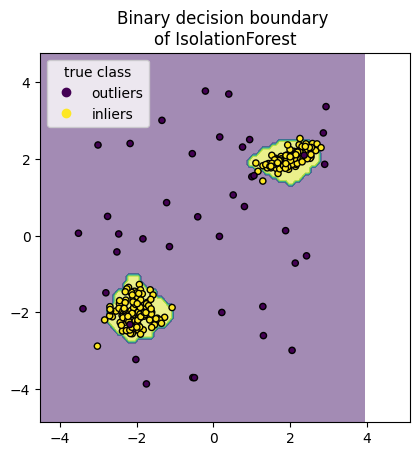

In [ ]:
disp = DecisionBoundaryDisplay.from_estimator(
    clf,
    X,
    response_method="predict",
    alpha=0.5,
)
disp.ax_.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor="k")
disp.ax_.set_title("Binary decision boundary \nof IsolationForest")
plt.axis("square")
plt.legend(handles=handles, labels=["outliers", "inliers"], title="true class")
plt.show()

### One-class SVM

#### Немного об SVM

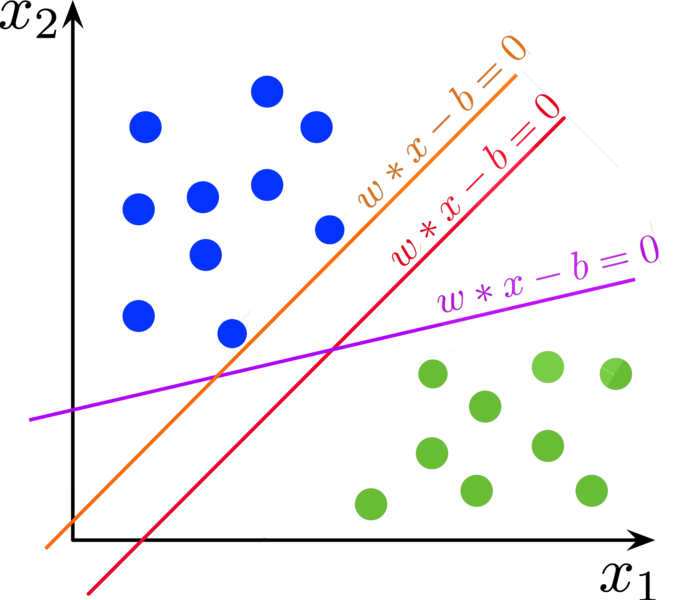

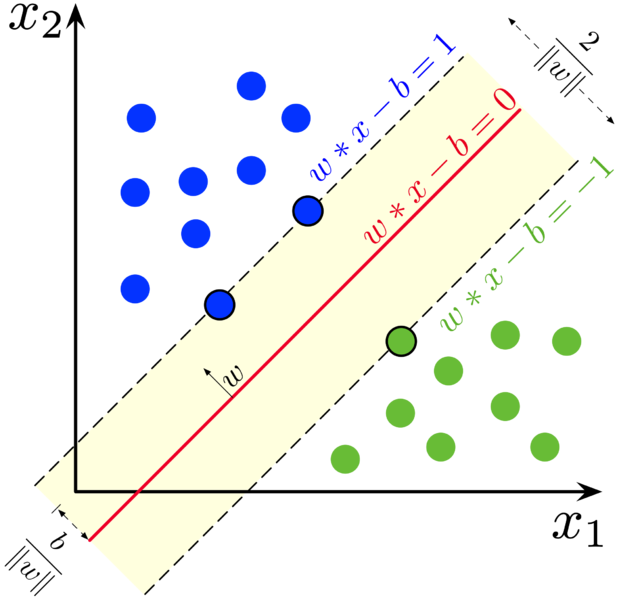

#### Почему метод **опорных векторов**?


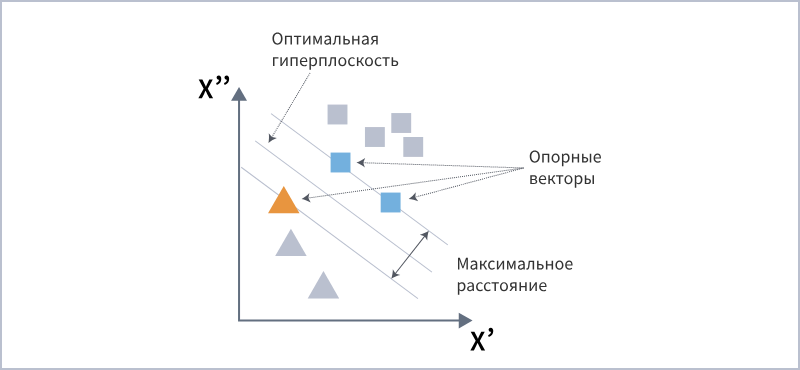

#### Детекция аномалий и **новизны**

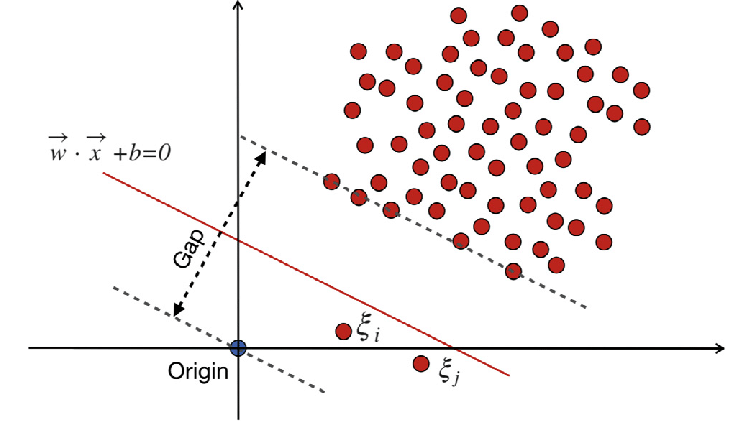

In [ ]:
X = 0.3 * rng.randn(500, 2)
X_train = np.r_[X + 2, X - 2]
X = 0.3 * rng.randn(20, 2)
X_test = np.r_[X + 2, X - 2]
X_outliers = rng.uniform(low=-4, high=4, size=(20, 2))

nu = 0.05
gamma = 2.0


clf = OneClassSVM(gamma=gamma, kernel="rbf", nu=nu)
clf.fit(X_train)
y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)
y_pred_outliers = clf.predict(X_outliers)
n_error_train = y_pred_train[y_pred_train == -1].size
n_error_test = y_pred_test[y_pred_test == -1].size
n_error_outliers = y_pred_outliers[y_pred_outliers == 1].size

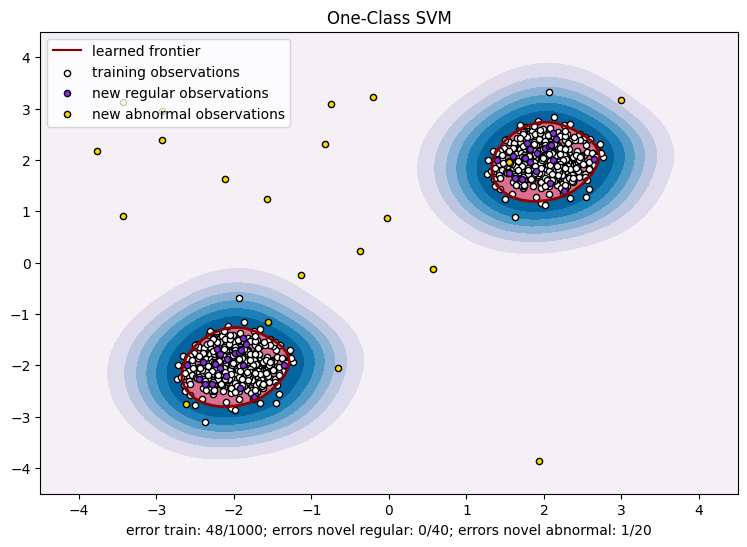

In [ ]:
_, ax = plt.subplots(figsize=(9, 6))

xx, yy = np.meshgrid(np.linspace(-4.5, 4.5, 50), np.linspace(-4.5, 4.5, 50))
X = np.concatenate([xx.ravel().reshape(-1, 1), yy.ravel().reshape(-1, 1)], axis=1)
DecisionBoundaryDisplay.from_estimator(
    clf,
    X,
    response_method="decision_function",
    plot_method="contourf",
    ax=ax,
    cmap="PuBu",
)
DecisionBoundaryDisplay.from_estimator(
    clf,
    X,
    response_method="decision_function",
    plot_method="contour",
    ax=ax,
    linewidths=2,
    colors="darkred",
    levels=[0],
)
DecisionBoundaryDisplay.from_estimator(
    clf,
    X,
    response_method="decision_function",
    plot_method="contourf",
    ax=ax,
    colors="palevioletred",
    levels=[0, clf.decision_function(X).max()],
)

s = 20
b1 = plt.scatter(X_train[:, 0], X_train[:, 1], c="white", s=s, edgecolors="k")
b2 = plt.scatter(X_test[:, 0], X_test[:, 1], c="blueviolet", s=s, edgecolors="k")
c = plt.scatter(X_outliers[:, 0], X_outliers[:, 1], c="gold", s=s, edgecolors="k")

ax.set(
    title="One-Class SVM",
    xlim=(-4.5, 4.5),
    ylim=(-4.5, 4.5),
    xlabel=(
        f"error train: {n_error_train}/{X_train.shape[0]}; "
        f"errors novel regular: {n_error_test}/{X_test.shape[0]}; "
        f"errors novel abnormal: {n_error_outliers}/{X_outliers.shape[0]}"
    ),
)
_ = ax.legend(
    [mlines.Line2D([], [], color="darkred", label="learned frontier"), b1, b2, c],
    [
        "learned frontier",
        "training observations",
        "new regular observations",
        "new abnormal observations",
    ],
    loc="upper left",
)